### Conceptual

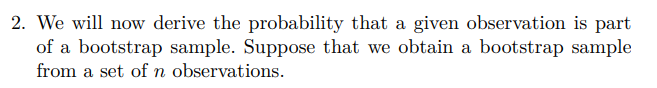

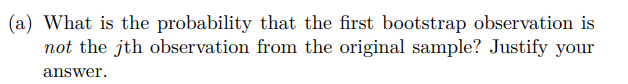

So, we assume that there are n observations, and we have some jth observation in those sample. Next, we are bootstrapping data, and the probability that first bootstrap observation is not those jth observation:
$$\frac{n-1}{n}$$
 Because there are n - 1 observations that satisfy condition.

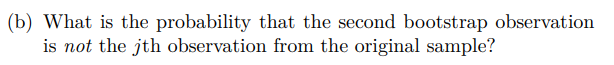

So, we know that the main idea of bootstrap is choose n observations from dataset WITH REPLACEMENT, which means that we can choose the same observation twice.

SO, based on this, answer is the same as in previous example, because for any ith in boostrap sample, we every time have n options to choose from:
$$\frac{n-1}{n}$$

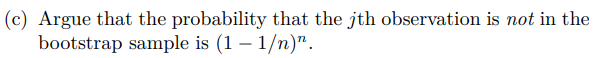

$$(1 - \frac{1}{n})^n$$

For example, in original dataset we have n = 30 observations. So, the probability that some jth observation in a original dataset will not be choosen during the bootstrab is:
$$(1 - \frac{1}{30})^{30}$$

So, how we can interpret it?

30 in power means that every time, when some observation is choosing by bootstrap, we have availible 30 obervations, since we can choose the same more than once. $\frac{29}{30}$ we can interpret like, the probability not to choose jth observatio  is $\frac{29}{30}$, because we have 29 availivle other, so, all this formula means that, during all 30 choices, we will not chosee jth observation

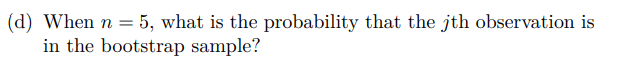

So, we have an original dataset with size n = 5. And we want to choose some 5 obs during the bootstrap with replacement. For every observation, we have a chance to choose some jth obs equal to:
$$\frac{1}{5}$$

But we can think in another way: lets assume that every time we will not choose jth observation:
$$(\frac{4}{5})^5$$

And the probability that at least one jth obs was chosen is:
$$1 - (\frac{4}{5})^5$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def jth_in_sample(n):
  return 1 - np.power(((n - 1) / n), n)

In [6]:
jth_in_sample(5)

0.6723199999999999

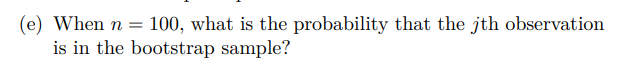

In [7]:
jth_in_sample(100)

0.6339676587267709

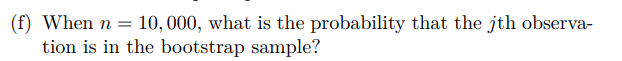

In [8]:
jth_in_sample(10000)

0.6321389535670295

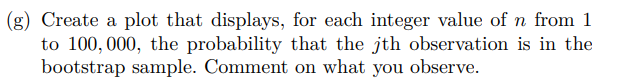

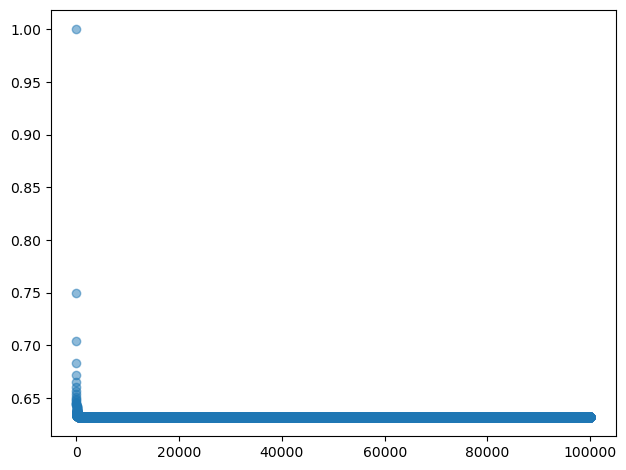

In [9]:
n = np.linspace(1, 100000, 100000)
prob = jth_in_sample(n)

plt.scatter(x=n, y=prob, alpha=0.5)
plt.tight_layout()

In [10]:
prob.min()

0.6321223982317534

So we see, that for some big n(almost for every n) the probability of some jth to be chosen during the bootstrap is not smaller than 0.63, which means that every time the probaiblity is $\frac{2}{3}$

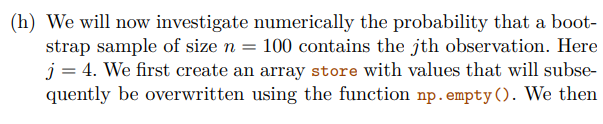
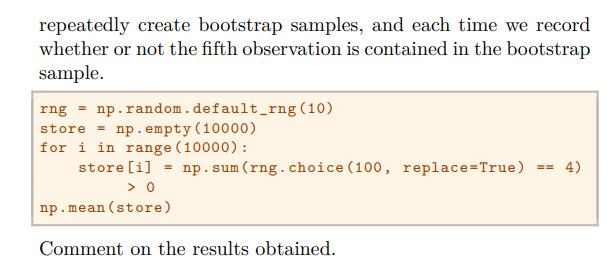

In [11]:
rng = np.random.default_rng(10)
store = np.empty(10000)
for i in range(10000):
  store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0

np.mean(store)

0.6362

So, we see that probability is the same as above

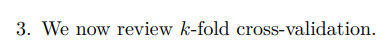

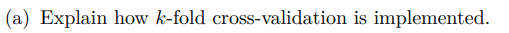

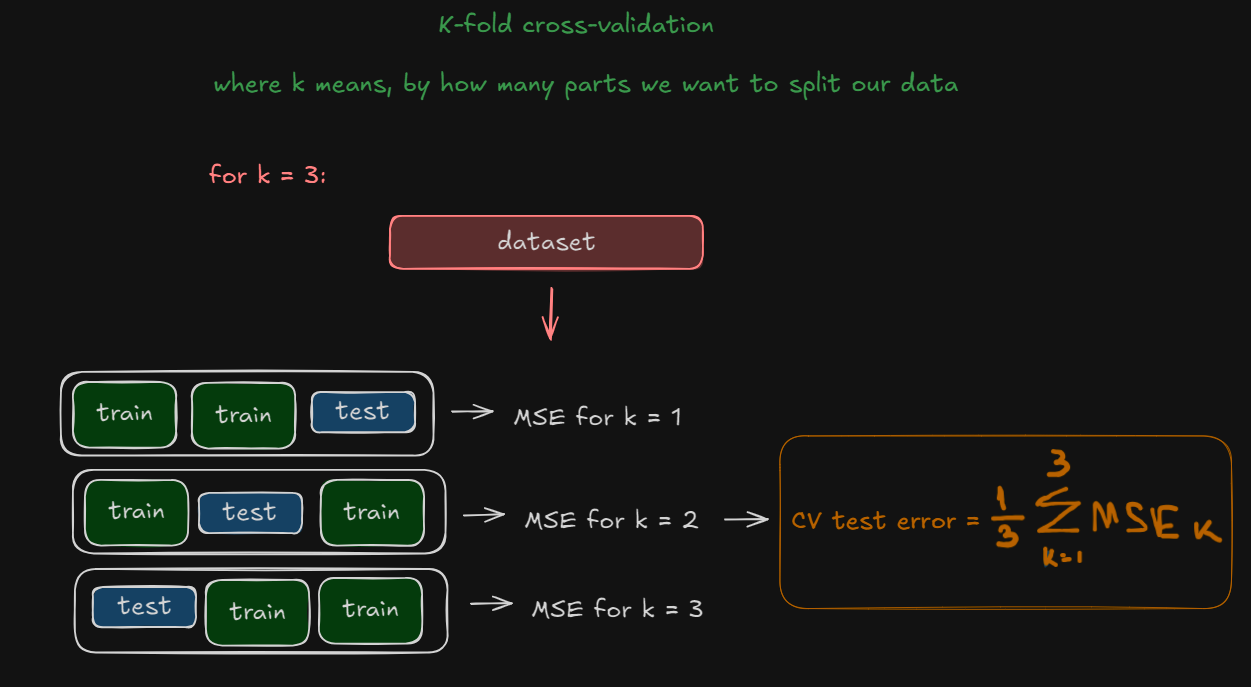

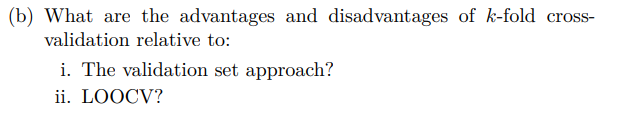

i. If we are talking about validation set approach, k-fold cross-validation is in many times better because:
- in validation approach, we split the the data in training and validation in proportion of 50/50, which means that model, fitted by 50% of observations from dataset can have high bias, because it had small traninf set to observe all patterns in data
- on other hand, k-fold cross-validatiob allows to choose optimal k(usually k = 5 or k = 10) and train model several times and take mean from all test errors. Also in this approach every observations once will be in a test set, so it guarantees to take into account every value
- Also, if we train model n times using validation approach and k-fold cross-validation, we will see that test error will strongly varied in validation approach and almost the same in k-fold cross-validation.

ii. LOOCV approach is a special case of k-fold cross-validation, where k = n - the size of dataset, which means that we train model n times, where traninf set is all n - 1 data, and test set is that nth observation. At first, you can think that this approach is better than k-fold cross-validation since it takes every single point into account but it has some significant drawbacks:
- the time implementation is verryyyy big ang k-fold cross-validation will be much faster
- also, LOOCV for every iteration takes almost the same traning set to fit the model, which can significantly increase the variance, since the model will recieve every time almost the same traning set

I can tell only one drawback about k-fold validation: variability that depends on chosen k, but in most cases with right chosen k this variability does not play a role

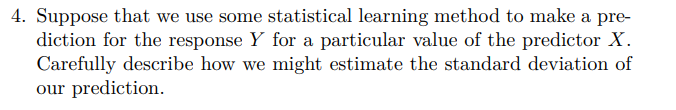

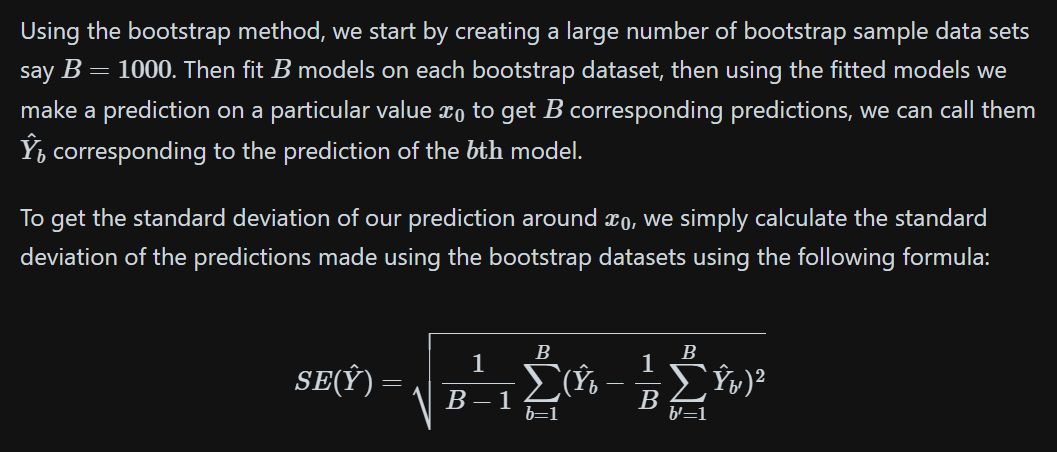

### Applied

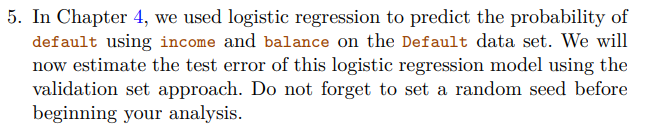

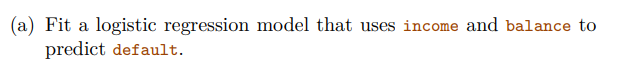

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
summarize,
poly)
from sklearn.model_selection import train_test_split

from functools import partial
from sklearn.model_selection import \
(cross_validate,
KFold,
ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

In [13]:
default = load_data("Default")
default["default"].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [14]:
design_matrix = MS(["income", "balance"])
X = design_matrix.fit_transform(default)
y = default["default"] == "Yes"

glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


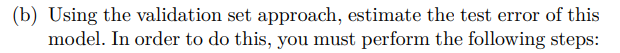

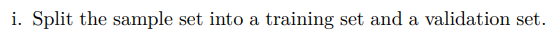

In [15]:
half = len(default) // 2
half

5000

In [16]:
train_set, validation_set = train_test_split(default, test_size=half, random_state=1)
len(train_set)

5000

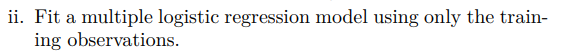

In [17]:
X_train = design_matrix.fit_transform(train_set)
y_train = train_set["default"] == "Yes"
X_validate = design_matrix.transform(validation_set)
y_validate = validation_set["default"] == "Yes"

glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm.fit()

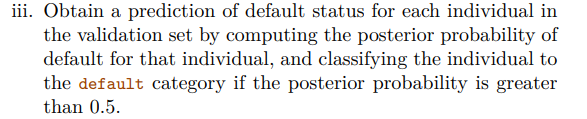

In [18]:
pred_proba = results.predict(X_validate)
pred_proba[:10]

9953    0.001043
3850    0.007651
4962    0.000819
3886    0.003422
5437    0.102399
8517    0.043765
2041    0.001738
1989    0.006813
1933    0.001910
9984    0.003484
dtype: float64

In [19]:
pred_labels = np.array(["No"] * pred_proba.shape[0], dtype=object)
pred_labels[pred_proba > 0.5] = "Yes"

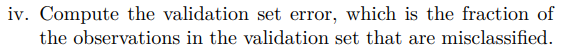

In [20]:
confusion_table(pred_labels, validation_set["default"])

Truth,No,Yes
Predicted,,
No,4817,101
Yes,24,58


$$\text{test error} = \frac{1}{n} \sum_{i=1}^{n} \text{Err}_i,$$
where $\text{Err}_i = I(y_i \neq \hat{y}_i)$.

In [21]:
np.mean(pred_labels != validation_set["default"])

0.025

So, we see that the valiation error is 0.25%, given that we use only 50% of our dataset to fit!

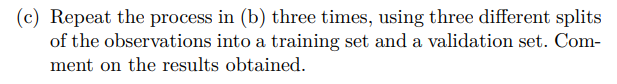

In [22]:
def fit_predict_by_valid_apprch(random_seed):
  half = len(default) // 2
  train_set, validation_set = train_test_split(default, test_size=half, random_state=random_seed)
  
  X_train = design_matrix.fit_transform(train_set)
  y_train = train_set["default"] == "Yes"
  X_validate = design_matrix.transform(validation_set)
  L_validate = validation_set["default"]

  glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
  results = glm.fit()
  print(summarize(results))
  
  pred_proba = results.predict(X_validate)
  
  pred_labels = np.array(["No"] * pred_proba.shape[0], dtype=object)
  pred_labels[pred_proba > 0.5] = "Yes"
  
  print(confusion_table(pred_labels, L_validate))
  print(np.mean(pred_labels != L_validate))
  return np.mean(pred_labels != L_validate)

In [23]:
rng = np.random.default_rng()
random_seed = rng.choice(100)
errors = np.empty(10)

for i in range(10):
  random_seed = rng.choice(100)
  print(" ")
  errors[i] = fit_predict_by_valid_apprch(random_seed)
  print(" ")
  
print(f"std: {errors.std()}")
print(f"min: {errors.min()}")
print(f"max: {errors.max()}")

 
                coef   std err       z  P>|z|
intercept -11.688500  0.619000 -18.894    0.0
income      0.000025  0.000007   3.496    0.0
balance     0.005700  0.000000  17.819    0.0
Truth        No  Yes
Predicted           
No         4820  107
Yes          21   52
0.0256
 
 
                coef   std err       z  P>|z|
intercept -11.170900  0.582000 -19.185  0.000
income      0.000017  0.000007   2.444  0.015
balance     0.005600  0.000000  18.053  0.000
Truth        No  Yes
Predicted           
No         4818  104
Yes          26   52
0.026
 
 
                coef   std err       z  P>|z|
intercept -11.822700  0.620000 -19.058  0.000
income      0.000022  0.000007   3.210  0.001
balance     0.005800  0.000000  17.699  0.000
Truth        No  Yes
Predicted           
No         4818  110
Yes          22   50
0.0264
 
 
                coef   std err       z  P>|z|
intercept -12.119000  0.643000 -18.862  0.000
income      0.000021  0.000007   2.983  0.003
balance     0.006000  0.

So, we see a little variation of test errors

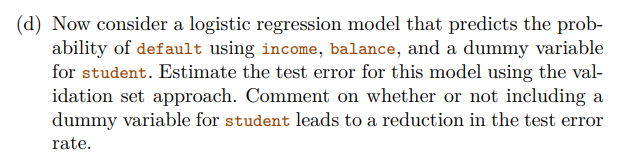

In [24]:
features = default.drop("default", axis=1).columns
design_matrix = MS(features)

errors = np.empty(10)

for i in range(10):
  random_seed = rng.choice(100)
  print(" ")
  errors[i] = fit_predict_by_valid_apprch(random_seed)
  print(" ")
  
print(f"std: {errors.std()}")
print(f"min: {errors.min()}")
print(f"max: {errors.max()}")

 
                   coef   std err       z  P>|z|
intercept    -10.530500  0.679000 -15.512  0.000
student[Yes]  -1.036400  0.329000  -3.150  0.002
balance        0.005900  0.000000  17.975  0.000
income        -0.000009  0.000012  -0.775  0.438
Truth        No  Yes
Predicted           
No         4824  107
Yes          24   45
0.0262
 
 
                   coef   std err       z  P>|z|
intercept    -11.123800  0.721000 -15.421  0.000
student[Yes]  -0.811000  0.340000  -2.382  0.017
balance        0.006100  0.000000  17.462  0.000
income        -0.000006  0.000012  -0.508  0.611
Truth        No  Yes
Predicted           
No         4815  118
Yes          21   46
0.0278
 
 
                   coef   std err       z  P>|z|
intercept    -10.801000  0.739000 -14.609  0.000
student[Yes]  -0.948000  0.346000  -2.740  0.006
balance        0.005800  0.000000  16.863  0.000
income        -0.000006  0.000012  -0.497  0.620
Truth        No  Yes
Predicted           
No         4807  126
Yes       

It is not a big change of test error, but adding "student" feature make "income" be non-significant in cause of big p-value

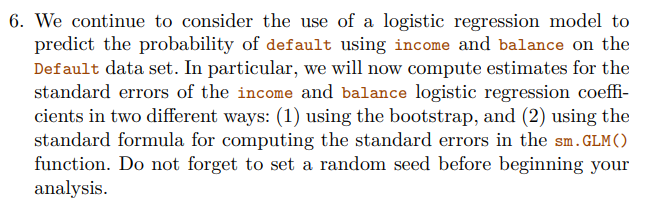

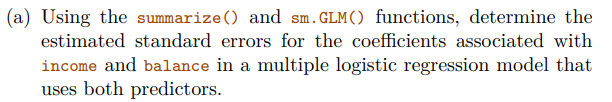

In [25]:
design_matrix = MS(["income", "balance"])

X = design_matrix.fit_transform(default)
y = default["default"] == "Yes"

glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()

summarize(results)

,coef,std err,z,P>|z|
intercept,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


In [26]:
summarize(results)["coef"][1:]

income     0.000021
balance    0.005600
Name: coef, dtype: float64

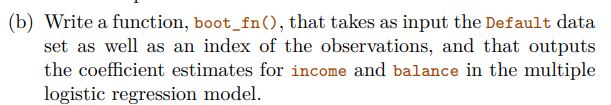

In [27]:
def boot_fn(data, idx):
  bootstraped_data = data.loc[idx]
  
  design_matrix = MS(["income", "balance"])
  
  X = design_matrix.fit_transform(bootstraped_data)
  y = bootstraped_data["default"] == "Yes"

  glm = sm.GLM(y, X, family=sm.families.Binomial())
  results = glm.fit()

  stats = summarize(results)
  return stats["coef"][1:]

In [28]:
rng = np.random.default_rng()
idx = rng.choice(default.shape[0], default.shape[0])
idx

array([6254, 6920, 9318, ..., 8373, 1848, 4688], dtype=int64)

In [29]:
boot_fn(default, idx)

income     0.000014
balance    0.005400
Name: coef, dtype: float64

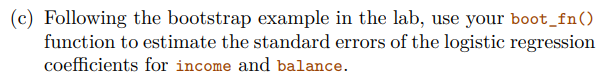

In [30]:
def boot_SE(func, D, n=None, B=1000, seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or D.shape[0]
    for _ in range(B):
        idx = rng.choice(D.index, n, replace=True)
        value = func(D, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)


$$\mathrm{SE}_{\mathrm{bootstrap}}=\sqrt{\frac{1}{B}\sum_{i=1}^B\theta_i^2-\left(\frac{1}{B}\sum_{i=1}^B\theta_i\right)^2}$$

In [31]:
params_SE = boot_SE(boot_fn,
                    default,
                    B=1000,
                    seed=0)
params_SE

income     0.000005
balance    0.000233
Name: coef, dtype: float64

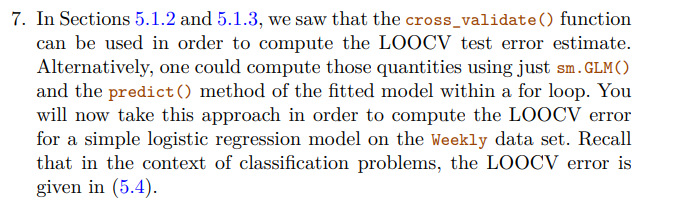

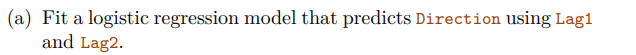

In [32]:
weekly = load_data("Weekly")
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [33]:
def fit_predict_weekly(features, idx = weekly.index):
  data = weekly.loc[idx]
  design_matrix = MS(features)
  
  X = design_matrix.fit_transform(data)
  y = data["Direction"] == "Up"
  
  glm = sm.GLM(y, X, family=sm.families.Binomial())
  results = glm.fit() 
  
  return results

In [34]:
fit_predict_weekly(["Lag1", "Lag2"])

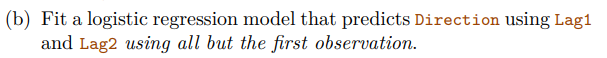

In [35]:
model = fit_predict_weekly(["Lag1", "Lag2"], weekly.index[1:])

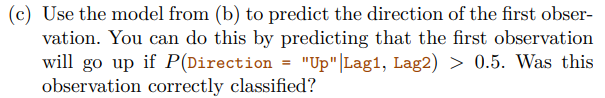

In [36]:
model.params

intercept    0.223243
Lag1        -0.038433
Lag2         0.060848
dtype: float64

In [37]:
lag1, lag2 = weekly[["Lag1", "Lag2"]].iloc[0]
direction = weekly["Direction"].iloc[0]

print(lag1)
print(lag2)
print(direction)

0.816
1.5719999999999998
Down


In [38]:
test_data = pd.DataFrame({
  "const": [1],
  "Lag1": [lag1],
  "Lag2": [lag2]
})

pred_proba = model.predict(test_data).iloc[0]
pred_label = "Yes" if pred_proba > 0.5 else "No"
pred_label

'Yes'

$$P(Direction = "Up"|Lag1, Lag2) > 0.5$$

Out first obseravtion had class "Down", but our model classified it as "Up" - failure

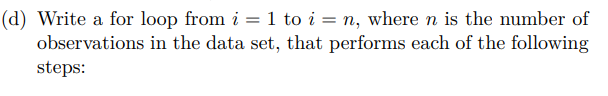

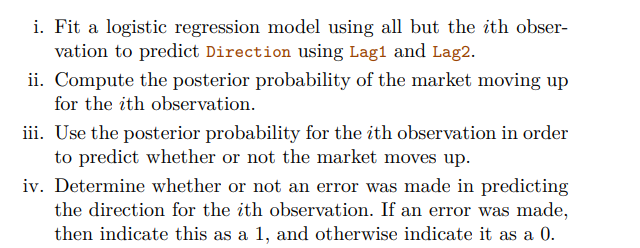

$$\text{CV}_{(n)} = \frac{1}{n} \sum_{i=1}^{n} \text{Err}_i,$$
where $\text{Err}_i = I(y_i \neq \hat{y}_i)$

In [39]:
def indicator(y_true, y_pred):
  return y_true != y_pred

In [40]:
errors = np.empty(weekly.shape[0])

for i in range(weekly.shape[0]):
  idx = weekly.drop(index=i).index
  model = fit_predict_weekly(["Lag1", "Lag2"], idx)
  
  test_row = weekly.iloc[i]
  test_data = pd.DataFrame({
    "const": [1],
    "Lag1": [test_row["Lag1"]],
    "Lag2": [test_row["Lag2"]]
  })
  true_i_direction = test_row["Direction"] 
  
  pred_i_direction = "Up" if model.predict(test_data).iloc[0] > 0.5 else "Down"
  errors[i] = indicator(true_i_direction, pred_i_direction)
  
np.mean(errors)

0.44995408631772266

So, what we can say: we have done LOOCV, and get LOOCV test error = 0.45%, so the accuracy rate = 0.55%, so it is not strange that our model had not correctly predict direction at (c)

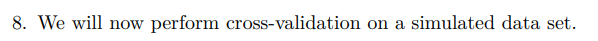

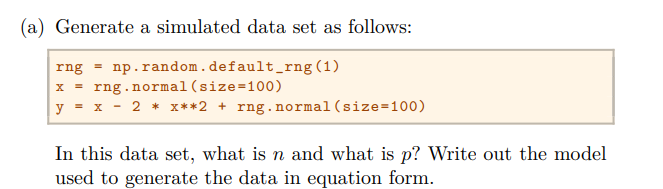

In [78]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

So, we can write an equation that represents our created model:
$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_1^{2} + \varepsilon
$$,
where:
- $\beta_0 = 0$
- $\beta_1 = 1$
- $\beta_2 = -2$

we have two predictors - $X$ and $X^{2}$


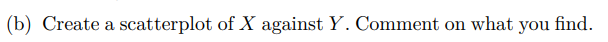

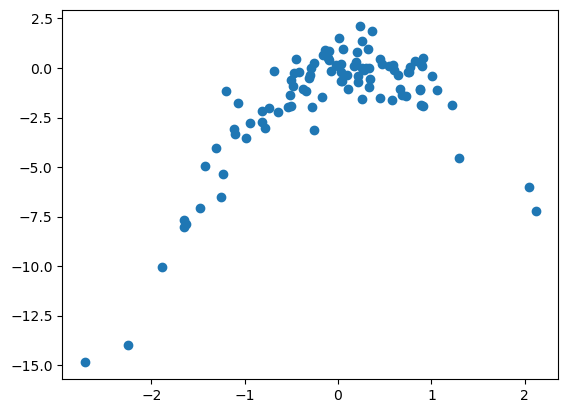

In [42]:
plt.scatter(x, y)

so, we see that x and y has some non-linear pattern, since y was created by $x$ and $x^{2}$

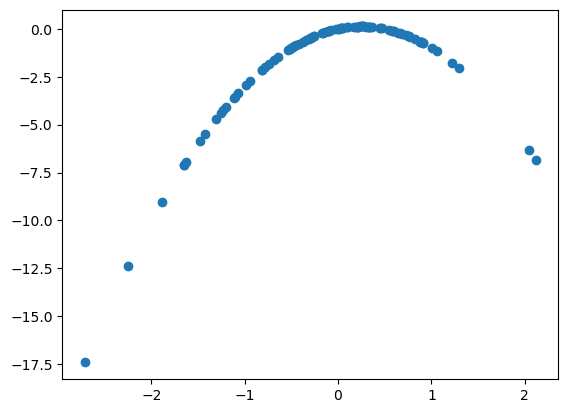

In [43]:
y = x - 2 * x**2
plt.scatter(x, y)

Also we see, how noise affects the data, but in our example, noise is normally distributed with SD = 1

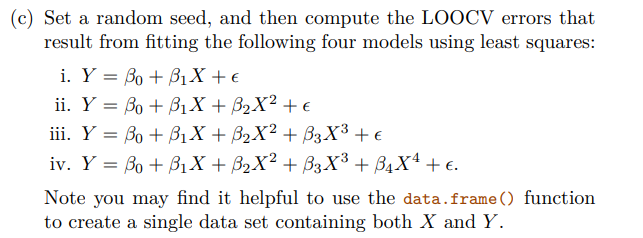

$$CV(k) = \frac{1}{k} \sum_{i=1}^{k} MSE_i$$

In [75]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

seed = 1

cv = KFold(n_splits=x.shape[0],
           shuffle=True,
           random_state=seed) 

cv_error = np.zeros(4)
M = sklearn_sm(sm.OLS)
for i, d in enumerate(range(1,5)):
    X = np.power.outer(x, np.arange(d+1))
    M_CV = cross_validate(M,
                          X,
                          y,
                          cv=cv)
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([6.63302984, 1.12293686, 1.30179655, 1.33239427])

In [76]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

seed = 2

cv = KFold(n_splits=x.shape[0],
           shuffle=True,
           random_state=seed) 

cv_error = np.zeros(4)
M = sklearn_sm(sm.OLS)
for i, d in enumerate(range(1,5)):
    X = np.power.outer(x, np.arange(d+1))
    M_CV = cross_validate(M,
                          X,
                          y,
                          cv=cv)
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([6.63302984, 1.12293686, 1.30179655, 1.33239427])

So, here we see, that the MSE are the same for random_state = 1 and 2 and this is obvious, because no matter how we shuffle the data, every obs in LOOCV will be a single test set, and we will have the same training sets but in another order

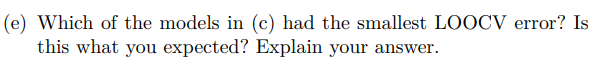

Quadratic model had the smallest MSE and this is obvious because y was created by $X_1 - 2 * X_1^{2}$

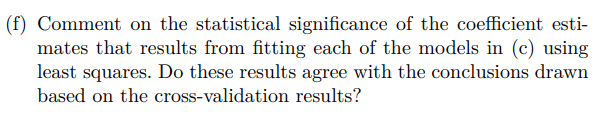

In [77]:
for i, d in enumerate(range(1,5)):
    X = np.power.outer(x, np.arange(d+1))
    results = sm.OLS(y, X).fit()
    print(summarize(results))
    print()

         coef  std err      t  P>|t|
const -1.4650    0.247 -5.937    0.0
x1     1.9494    0.289  6.752    0.0

         coef  std err       t  P>|t|
const -0.0728    0.119  -0.611  0.543
x1     0.9663    0.126   7.647  0.000
x2    -2.0047    0.091 -22.072  0.000

         coef  std err       t  P>|t|
const -0.0572    0.120  -0.477  0.635
x1     1.1146    0.187   5.945  0.000
x2    -2.0471    0.099 -20.673  0.000
x3    -0.0643    0.060  -1.070  0.287

         coef  std err       t  P>|t|
const  0.1008    0.136   0.743  0.460
x1     0.9050    0.205   4.423  0.000
x2    -2.5059    0.221 -11.336  0.000
x3     0.0338    0.073   0.466  0.642
x4     0.1042    0.045   2.309  0.023



So, we can see, that for x3 and x4 we have big p-values that tells us that corresponding b3 and b4 equal to 0 and has no influence on y. And this is obvious, since y was created by a quadratic functin with normal distribution. And cross-validation also shows that second model has the smallest MSE

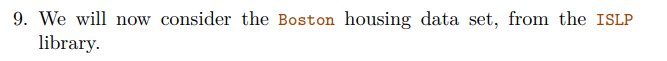

In [80]:
boston = load_data("Boston")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


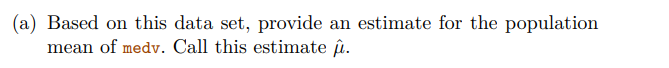

In [81]:
medv_mean = boston["medv"].mean()
medv_mean

22.532806324110677

$$\hat µ = 22.532806324110677$$

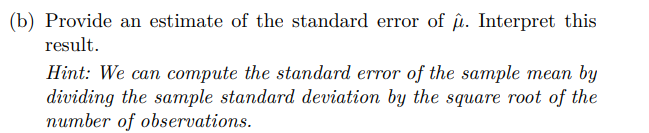

$$ SE(\hat µ) = \frac{SD(\hat µ)}{\sqrt{n}} $$

In [113]:
std = boston["medv"].std()
n = np.sqrt(boston.shape[0])

se = std / n
se

0.4088611474975351

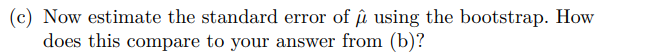

In [87]:
n = boston.shape[0]
n

506

In [109]:
def bootstrap(x, n, B=1000):
  rng = np.random.default_rng()
  standard_errors = np.empty(B)
  
  for i in range(B):
    idx = rng.choice(n, size=n, replace=True)
    new_x = x.loc[idx]
    
    standard_errors[i] = new_x.std() / np.sqrt(n)
    
  return np.mean(standard_errors)

In [111]:
boot_se = bootstrap(boston["medv"], boston.shape[0], 1000)
boot_se

0.4080535247392989

So, we see that using bootstrap generated sample, not population, we got almost the same standard error

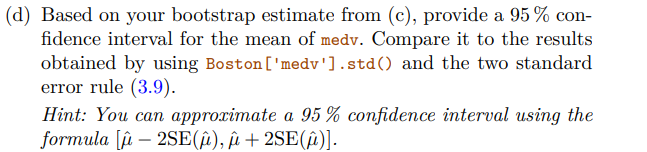

$$conf.interval = [\hat µ − 2SE(\hat µ), \hat µ + 2SE(\hat µ)]$$

In [116]:
#boostraped SE

[medv_mean - 2 * boot_se, medv_mean + 2 * boot_se]

[21.716699274632077, 23.348913373589276]

In [115]:
#population SE

[medv_mean - 2 * se, medv_mean + 2 * se]

[21.715084029115605, 23.35052861910575]

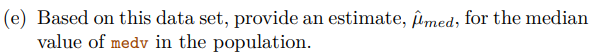

In [118]:
medv_median = boston["medv"].median()
medv_median

21.2

$$\hat µ_{med} = 21.2$$